In [2]:
import datasets as ds
import matplotlib.pyplot as plt
import re

from huggingface_hub import login

import help_lib as hb


login()

In [3]:
STUDENT_MODEL = "google/gemma-3-1b-it"
DATASET = "HuggingFaceTB/Countdown-Task-GOLD"

SPLIT_7B = "verified_Qwen2.5-7B-Instruct"
SPLIT_4B = "verified_Qwen3-4B-Instruct-2507"

seed = 42

# Загрузка данных

In [4]:
dataset1 = ds.load_dataset(DATASET, SPLIT_7B)
dataset2 = ds.load_dataset(DATASET, SPLIT_4B)
dataset3 = ds.load_dataset("json", data_files="data/raw_teacher_countdown_1.jsonl")
dataset4 = ds.load_dataset("json", data_files="data/raw_teacher_countdown_2.jsonl")


dataset = ds.concatenate_datasets([
    dataset1["train"], 
    dataset2["train"], 
    dataset3["train"], 
    dataset4["train"]
]).shuffle(seed=seed)

dataset_original = ds.concatenate_datasets([
    dataset1["train"], 
    dataset2["train"]
])


test_dataset = ds.load_dataset("csv", data_files="data/test_public.csv")["train"]

In [5]:
dataset, test_dataset

(Dataset({
     features: ['target', 'nums', 'messages'],
     num_rows: 60273
 }),
 Dataset({
     features: ['id', 'target', 'nums'],
     num_rows: 2000
 }))

In [6]:
def graph_target_distribution(dataset, test_dataset):
    
    train_targets_1_verified = len(dataset.filter(lambda x: len(str(x["target"])) == 1))
    test_targets_1 = len(test_dataset.filter(lambda x: len(str(x["target"])) == 1))

    train_targets_2_verified = len(dataset.filter(lambda x: len(str(x["target"])) == 2))
    test_targets_2 = len(test_dataset.filter(lambda x: len(str(x["target"])) == 2))

    train_targets_3m_verified = len(dataset.filter(lambda x: len(str(x["target"])) >= 3))
    test_targets_3m = len(test_dataset.filter(lambda x: len(str(x["target"])) >= 3))



    labels = ["1 digit", "2 digits", "3+ digits"]

    train_verified = [train_targets_1_verified, train_targets_2_verified, train_targets_3m_verified]
    test = [test_targets_1, test_targets_2, test_targets_3m]

    _, axes = plt.subplots(1, 2, figsize=(10, 4))
    colors = ["#4CAF50", "#2196F3", "#FF9800"]

    datasets = [
        ("Train (verified)", train_verified),
        ("Test", test)
    ]

    for ax, (title, data) in zip(axes, datasets):
        bars = ax.bar(labels, data, color=colors)

        ax.set_title(title)
        ax.set_xlabel("Target length")
        ax.set_ylabel("Count")

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height,
                    str(height),
                    ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

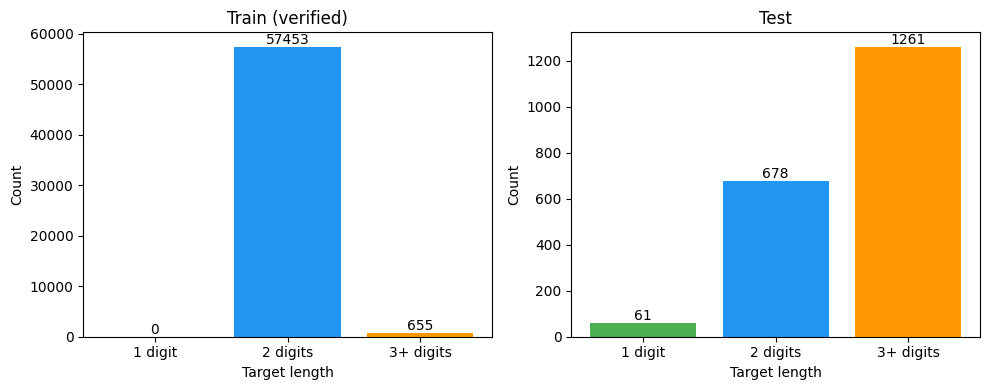

In [7]:
graph_target_distribution(dataset_original, test_dataset)

Как можно заметить выше на диаграмме, в test_dataset очень много  трёхзначных target'ов, при этом в train датасете их меньше 1%. Распределение данных, на которых мы собираемся учиться, если взять просто весь датасет train, очень разниться с распределением данных на test.  

Я это заметил, когда у меня был высокий Acc на валидации (подмножество train), но при этом очень маленький скор на test. Тогда я решил посмотреть, какие предсказания делает моя модель на test и заметил, что она просто не понимает, что такое трехзначные числа, и не может составить хороший ответ.   

Поэтому я использовал дополнительную генерацию ответов учителя на синтетически составленных задачах.

Ниже можно посмотреть распределение после генерации дополнительных ответов учителя

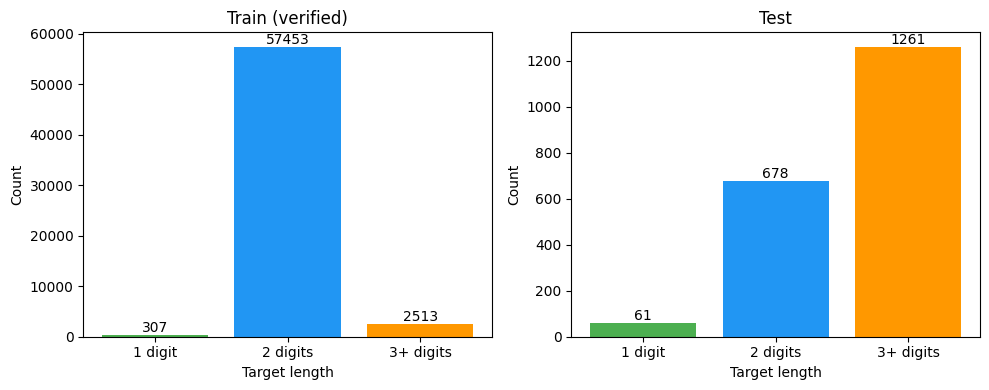

In [8]:
graph_target_distribution(dataset, test_dataset)

К сожалению нагенерировать сильно много примеров не получилось из за нехватки времени, но эмпирически оказалось, что сильно большой датасет и не нужен для обучения модели.

# Подготовка данных

In [13]:
def clean_math_segment(segment):
    cleaned = hb.PREFIX_RE.sub('', segment.strip(), count=1)
    cleaned = re.sub(r'[\s→]+$', '', cleaned)
    
    return cleaned.strip()


def distill_reasoning(text):
    text = text.replace('−', '-').replace('—', '-').replace('×', '*').replace('÷', '/')

    content = text
    think_match = hb.THINK_RE.search(text)
    if think_match:
        content = think_match.group(1)

    raw_segments = hb.MATH_EXPRESSION_RE.findall(content)
    
    cleaned_steps = []
    for seg in raw_segments:
        step = clean_math_segment(seg)
        if '=' in step and any(char.isdigit() for char in step):
            cleaned_steps.append(step)
    
    unique_steps = []
    for step in cleaned_steps:
        if step not in unique_steps:
            unique_steps.append(step)
            
    distilled_think = "\n".join(unique_steps)
    answer_match = hb.ANSWER_RE.search(text)
    answer_part = f"\n<answer>{answer_match.group(1).strip()}</answer>" if answer_match else ""
    
    return f"<think>\n{distilled_think}\n</think>{answer_part}"


def get_new_message(nums, target, answer=None) -> list[dict]:    
    system = {
        "role": "system",
        "content":(
            "Solve Countdown. Use ALL given numbers ONCE to reach target."
            "Format: <think> steps with = </think> <answer> final equation </answer>. Be concise."
        )
    }
    
    user = {
        "role": "user",
        "content": f"Target: {target} | Numbers: {nums}"
    }
    
    if answer:
        return [system, user,
                {
                    "role": "assistant",
                    "content": answer
                }
        ]
    
    return [system, user]


def preprocess_test(row):
    target = int(row["target"])
    nums = [int(num) for num in row["nums"][1:-1].split(", ")]
    messages = get_new_message(nums, target)
    
    return {
        "target": target,
        "nums": nums,
        "messages": messages
    }



def get_answer_blocks(messages: list[dict[str, str]]) -> list[str]:
    assistant = ""
    for d in messages:
        if d["role"] == "assistant":
            assistant = d["content"]
            
    assert assistant != "", "Train data needs 'role' assistant for learning"
    answers = hb.ANSWER_RE.findall(assistant)
    if answers is None:
        raise ValueError(f"assistant has incorrect answer: {assistant}")
    
    return answers


def format_promt(dataset: ds.Dataset) -> ds.Dataset:
    rows = [] 
    for i in range(len(dataset)):
        row = dataset[i]
        
        target: int = row["target"]
        nums: list[int] = row["nums"]
        messages: list[dict] = row["messages"]
        
        assistant_content = messages[-1]["content"]
        
        answer_blocks = get_answer_blocks(messages)
        if len(answer_blocks) != 1:
            continue
        
        reasoning_answer = distill_reasoning(assistant_content)
        new_messages = get_new_message(nums, target, reasoning_answer)
        rows.append({
            "target": target,
            "nums": nums,
            "messages": new_messages
        })
            
    return ds.Dataset.from_list(rows)


def filter_valid_equation(row):
    target: int = row["target"]
    nums: list[int] = row["nums"]
    messages: list[dict] = row["messages"]
    
    content = messages[-1]["content"]
    equation = hb.extract_generated_equation(hb.extract_last_answer(content))
    
    return hb.is_valid_equation(equation, nums, target)

In [14]:
test_dataset = test_dataset.map(preprocess_test)

dataset = format_promt(dataset)
dataset = dataset.filter(filter_valid_equation)

Filter: 100%|██████████| 60257/60257 [00:02<00:00, 26116.93 examples/s]


In [15]:
test_dataset[0]

{'id': 0,
 'target': 870,
 'nums': [11, 83, 62, 23, 68],
 'messages': [{'role': 'system',
   'content': 'Solve Countdown. Use ALL given numbers ONCE to reach target.Format: <think> steps with = </think> <answer> final equation </answer>. Be concise.'},
  {'role': 'user', 'content': 'Target: 870 | Numbers: [11, 83, 62, 23, 68]'}]}

In [19]:
for d in dataset[1]["messages"]:
    role = d["role"]
    content = d["content"]
    
    print(f"role: {role}\ncontent:\n{content}\n")

role: system
content:
Solve Countdown. Use ALL given numbers ONCE to reach target.Format: <think> steps with = </think> <answer> final equation </answer>. Be concise.

role: user
content:
Target: 10 | Numbers: [49, 54, 93]

role: assistant
content:
<think>
93 - 54 = 39
93 - 49 = 44
54 - 49 = 5
(93 - 54) = 39
39 - 49 = -10
(93 - 49) = 44
44 - 54 = -10
(54 - 49) = 5
93 / 5 = 18.6
(93 + 49) = 142
142 - 54 = 88
(54 + 49) = 103
103 - 93 = 10
54 + 49 = 103
(54 + 49) - 93 = 10
</think>
<answer>(54 + 49) - 93 = 10</answer>



Я сделал несколько важных изменений в обучающем датасете:  
1. Изменил промт на более краткий, при этом правильно передал смысл задачи.
2. Оставил минимальные рассуждения учителя (только математические преобразования - самое главное. Маленькая модель не может держать большой контекст рассуждений)  

Соответственно над тестовым датасетом я сделал аналогичные преобразования.

In [13]:
dataset.save_to_disk("data/dataset")
test_dataset.save_to_disk("data/test_dataset")

Saving the dataset (1/1 shards): 100%|██████████| 2000/2000 [00:00<00:00, 62062.90 examples/s]
